# Marginal F1 gains across consecutive feature intervals

Reads `cgfs_f1_marginal_gains.csv` and produces the box-plot of marginal
F1-score gains over the intervals $0\to5$, $5\to10$, $10\to15$, $15\to20$ and
$20\to25$, for weighted CGFS.

**What is in the CSV.** One row per (dataset, classifier, interval): 75 rows from
3 datasets $\times$ 5 classifiers $\times$ 5 intervals, so each box summarises 15
values. `gain` is the increase in weighted F1 obtained by moving from `k_from` to
`k_to` features, with `f1_from = 0` at the first interval, since a model with no
features has zero F1. The gains telescope exactly: for every series they sum to
the F1-score at $k=25$.

The F1 values are the seed-means already present in the aggregated files, so each
box shows variation **across datasets and classifiers**, not across seeds. If you
want the seed-level spread as well, regenerate the CSV from the per-run raw files
using the appendix at the end; that gives 45 values per box instead of 15.

**A caveat on interpretation, stated here because the figure invites the
opposite reading.** The quantity plotted is the gain in downstream F1, which is
*not* the submodular objective CGFS maximises. Coverage $\mathcal{G}$ is
submodular and its marginal gains are provably non-increasing; F1 is a property
of a trained classifier and carries no such guarantee, so a non-monotone F1
profile is not evidence against submodularity, and a monotone one is not evidence
for it. The figure is properly read as showing where the useful information is
concentrated in the greedy ordering. The submodularity claim itself should rest
on the coverage trace.

## 1. Configuration

In [1]:
CSV_PATH = "cgfs_f1_marginal_gains.csv"
OUT_DIR  = "."
OUT_NAME = "cgfs_f1_marginal_gains"

AS_PERCENT  = False   # True plots percentage points instead of the 0-1 scale
SHOW_POINTS = False   # overlay the individual (dataset, classifier) values,
                      # coloured by dataset. Useful at 15 points per box, where a
                      # box plot's quartiles are estimated from very little data.
ANNOTATE_MEANS = True # print each interval's mean above its box

FIGSIZE = (7.6, 4.6)
BOX_FACE, BOX_EDGE, MEAN_COL = "#90EE90", "#006400", "#CC0000"

## 2. Load

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_PATH)

# Interval order follows the budgets themselves, not the order of rows.
order = (df[["k_from", "k_to", "interval"]].drop_duplicates()
           .sort_values(["k_from", "k_to"]))
intervals = order["interval"].tolist()
labels = [f"Gain {a}\u2192{b}" for a, b in zip(order["k_from"], order["k_to"])]

scale = 100.0 if AS_PERCENT else 1.0
data = [df.loc[df.interval == iv, "gain"].to_numpy() * scale for iv in intervals]

print(f"{len(df)} rows | {df.dataset.nunique()} datasets x {df.classifier.nunique()} "
      f"classifiers x {len(intervals)} intervals")
print(f"datasets   : {sorted(df.dataset.unique())}")
print(f"classifiers: {sorted(df.classifier.unique())}\n")

summary = (df.groupby("interval", sort=False)["gain"]
             .agg(n="count", mean="mean", median="median",
                  q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75),
                  min="min", max="max")
             .reindex(intervals))
print(summary.round(4).to_string())

75 rows | 3 datasets x 5 classifiers x 5 intervals
datasets   : ['CICIoT2023', 'Edge-IIoTset', 'RT-IoT2022']
classifiers: ['DT', 'GB', 'KNN', 'RF', 'SVM']

           n    mean  median      q1      q3     min     max
interval                                                    
0→5       15  0.7857  0.9460  0.6750  0.9667  0.2222  0.9953
5→10      15  0.1400  0.0200  0.0105  0.2752  0.0002  0.4944
10→15     15  0.0079  0.0015 -0.0004  0.0172 -0.0033  0.0192
15→20     15  0.0022  0.0004  0.0001  0.0018 -0.0247  0.0357
20→25     15  0.0074  0.0044  0.0010  0.0129  0.0000  0.0184


## 3. Figure

Box shows the interquartile range with the median as a line; the diamond is the
mean; points beyond $1.5\times$IQR from the quartiles are drawn individually; the
dashed line connects the means.

wrote ./cgfs_f1_marginal_gains.png
wrote ./cgfs_f1_marginal_gains.pdf


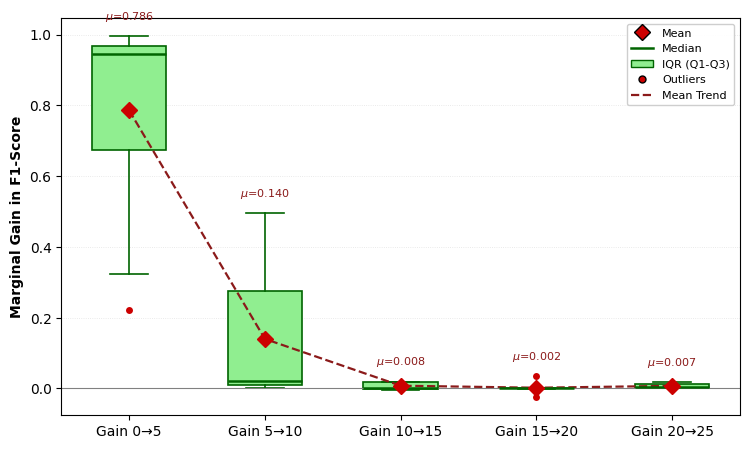

In [3]:
fig, ax = plt.subplots(figsize=FIGSIZE)

bp = ax.boxplot(
    data, patch_artist=True, widths=0.55, whis=1.5,
    medianprops=dict(color=BOX_EDGE, lw=1.8),
    boxprops=dict(facecolor=BOX_FACE, edgecolor=BOX_EDGE, lw=1.2),
    whiskerprops=dict(color=BOX_EDGE, lw=1.2),
    capprops=dict(color=BOX_EDGE, lw=1.2),
    flierprops=dict(marker="o", markerfacecolor=MEAN_COL, markeredgecolor="none",
                    markersize=5, linestyle="none"),
)

means = [d.mean() for d in data]
x = np.arange(1, len(data) + 1)
ax.plot(x, means, "--", color="#8B1A1A", lw=1.6, zorder=2)
ax.plot(x, means, "D", color=MEAN_COL, ms=8, zorder=3)

if SHOW_POINTS:
    rng = np.random.default_rng(0)
    dss = sorted(df.dataset.unique())
    pal = dict(zip(dss, ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]))
    for ds in dss:
        sub = df[df.dataset == ds]
        xs = [intervals.index(iv) + 1 + rng.uniform(-0.16, 0.16) for iv in sub.interval]
        ax.scatter(xs, sub["gain"] * scale, s=16, color=pal[ds], alpha=0.75,
                   edgecolors="none", zorder=4, label=ds)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Marginal Gain in F1-Score" + (" (pp)" if AS_PERCENT else ""),
              fontweight="bold")
ax.grid(axis="y", alpha=0.35, lw=0.6, ls=":")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_axisbelow(True)

if ANNOTATE_MEANS:
    span = max(max(d) for d in data) - min(min(d) for d in data)
    for xi, m, d in zip(x, means, data):
        ax.text(xi, max(d) + 0.035 * span, f"$\\mu$={m:.3f}",
                ha="center", va="bottom", fontsize=8, color="#8B1A1A")

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Line2D([], [], marker="D", color="none", markerfacecolor=MEAN_COL, markersize=8, label="Mean"),
    Line2D([], [], color=BOX_EDGE, lw=1.8, label="Median"),
    Patch(facecolor=BOX_FACE, edgecolor=BOX_EDGE, label="IQR (Q1-Q3)"),
    Line2D([], [], marker="o", color="none", markerfacecolor=MEAN_COL, markersize=5, label="Outliers"),
    Line2D([], [], color="#8B1A1A", lw=1.6, ls="--", label="Mean Trend"),
]
if SHOW_POINTS:
    handles += [Line2D([], [], marker="o", color="none", markerfacecolor=pal[d],
                       markersize=6, label=d) for d in dss]
ax.legend(handles=handles, fontsize=8, loc="upper right", framealpha=0.95)

fig.tight_layout()
os.makedirs(OUT_DIR, exist_ok=True)
for ext in ("png", "pdf"):
    p = os.path.join(OUT_DIR, f"{OUT_NAME}.{ext}")
    fig.savefig(p, dpi=300, bbox_inches="tight")
    print("wrote", p)
plt.show()

## 4. Numbers for the caption

In [4]:
parts = [f"$\\mu$={m:.3f} ({lab.replace('Gain ', '')})" for lab, m in zip(labels, means)]
print("Mean marginal gain per interval:")
for lab, m, d in zip(labels, means, data):
    print(f"  {lab:16s} mean={m:.4f}  median={np.median(d):.4f}  "
          f"IQR=[{np.percentile(d, 25):.4f}, {np.percentile(d, 75):.4f}]  "
          f"range=[{d.min():.4f}, {d.max():.4f}]")

neg = df[df.gain < 0]
if len(neg):
    print(f"\n{len(neg)} of {len(df)} series/interval pairs show a negative gain "
          f"(adding features lowered F1):")
    for _, r in neg.iterrows():
        print(f"  {r.dataset:13s} {r.classifier:4s} {r.interval:8s} {r.gain:+.4f}")
    print("These are genuine and should not be clipped: downstream F1 is not")
    print("monotone in the feature set, unlike the coverage objective.")

drop = means[0] / means[-1] if means[-1] else float("inf")
print(f"\nFirst interval mean is {drop:.0f}x the last.")

Mean marginal gain per interval:
  Gain 0→5         mean=0.7857  median=0.9460  IQR=[0.6750, 0.9667]  range=[0.2222, 0.9953]
  Gain 5→10        mean=0.1400  median=0.0200  IQR=[0.0105, 0.2752]  range=[0.0002, 0.4944]
  Gain 10→15       mean=0.0079  median=0.0015  IQR=[-0.0004, 0.0172]  range=[-0.0033, 0.0192]
  Gain 15→20       mean=0.0022  median=0.0004  IQR=[0.0001, 0.0018]  range=[-0.0247, 0.0357]
  Gain 20→25       mean=0.0074  median=0.0044  IQR=[0.0010, 0.0129]  range=[0.0000, 0.0184]

8 of 75 series/interval pairs show a negative gain (adding features lowered F1):
  RT-IoT2022    DT   10→15    -0.0007
  RT-IoT2022    GB   15→20    -0.0002
  RT-IoT2022    KNN  15→20    -0.0001
  RT-IoT2022    RF   10→15    -0.0005
  CICIoT2023    DT   10→15    -0.0004
  CICIoT2023    KNN  10→15    -0.0033
  CICIoT2023    KNN  15→20    -0.0247
  CICIoT2023    RF   10→15    -0.0007
These are genuine and should not be clipped: downstream F1 is not
monotone in the feature set, unlike the coverage obj

In [5]:
# Per-dataset breakdown: the pooled box hides which dataset drives each interval.
piv = (df.pivot_table(index="dataset", columns="interval", values="gain", aggfunc="mean")
         .reindex(columns=intervals))
print("Mean gain by dataset (averaged over the five classifiers)\n")
print(piv.round(4).to_string())

tex = [ "% Marginal F1 gains per feature interval, weighted CGFS.",
        "\\begin{table}[!t]\\centering\\small",
        "\\caption{Marginal gain in weighted F1-score over consecutive feature "
        "intervals for CGFS, pooled over three datasets and five classifiers "
        f"({len(df) // len(intervals)} values per interval).}}",
        "\\label{tab:f1_marginal_gains}",
        "\\begin{tabular}{l" + "c" * len(intervals) + "}", "\\toprule",
        "Statistic & " + " & ".join(iv.replace("\u2192", "$\\rightarrow$")
                                    for iv in intervals) + " \\\\", "\\midrule"]
for stat, fn in (("Mean", np.mean), ("Median", np.median),
                 ("Q1", lambda a: np.percentile(a, 25)),
                 ("Q3", lambda a: np.percentile(a, 75))):
    tex.append(f"{stat} & " + " & ".join(f"{fn(d) / scale:.4f}" for d in data) + " \\\\")
tex += ["\\bottomrule", "\\end{tabular}", "\\end{table}", ""]
p = os.path.join(OUT_DIR, f"{OUT_NAME}.tex")
open(p, "w").write("\n".join(tex))
print("\nwrote", p)

Mean gain by dataset (averaged over the five classifiers)

interval         0→5    5→10   10→15   15→20   20→25
dataset                                             
CICIoT2023    0.8283  0.1012  0.0022 -0.0026  0.0021
Edge-IIoTset  0.5899  0.2890  0.0179  0.0085  0.0057
RT-IoT2022    0.9389  0.0299  0.0035  0.0006  0.0145

wrote ./cgfs_f1_marginal_gains.tex


## Appendix: how the CSV was built

Provenance, so the figure can be regenerated if the underlying results change.
The aggregated files hold one row per (classifier, method, $k$) with the F1 mean
already averaged over seeds; the cell below keeps the `CGFS-weighted` rows,
reads F1 at each budget, and differences consecutive budgets.

To obtain seed-level spread instead, point `FILES` at the per-run raw files and
group by `seed` as well, which yields 45 values per interval.

In [6]:
REGENERATE = False        # set True to rebuild the CSV from the aggregated files

if REGENERATE:
    FILES = {"RT-IoT2022":   "cgfs_rt-iot_agg.csv",
             "Edge-IIoTset": "cgfs_edge-iiot_agg.csv",
             "CICIoT2023":   "cgfs_cic-iot_agg.csv"}
    KS = [5, 10, 15, 20, 25]
    rows = []
    for name, f in FILES.items():
        d = pd.read_csv(f)
        w = d[d.method == "CGFS-weighted"]
        for clf, g in w.groupby("classifier"):
            s = g.set_index("k")["f1_mean"]
            prev_k, prev = 0, 0.0            # no features -> F1 = 0
            for k in KS:
                rows.append({"dataset": name, "classifier": clf.upper(),
                             "k_from": prev_k, "k_to": k,
                             "interval": f"{prev_k}\u2192{k}",
                             "f1_from": prev, "f1_to": float(s.loc[k]),
                             "gain": float(s.loc[k]) - prev})
                prev_k, prev = k, float(s.loc[k])
    out = pd.DataFrame(rows)
    # The gains must telescope to the F1 at the final budget.
    for (ds, clf), g in out.groupby(["dataset", "classifier"]):
        assert abs(g.gain.sum() - g[g.k_to == KS[-1]].f1_to.iloc[0]) < 1e-12
    out.to_csv(CSV_PATH, index=False)
    print(f"wrote {CSV_PATH} ({len(out)} rows); telescoping check passed")
else:
    print("REGENERATE is False; using the CSV as shipped.")

REGENERATE is False; using the CSV as shipped.
